I will be building off of the chatbot defined in lab1 with my attempt at solving history conversations

### Import Libraries

In [79]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

In [80]:
load_dotenv(override=True)

True

### Define LLM

In [81]:
llm = ChatOpenAI(model = "gpt-4o-mini")

### Define State

In [82]:
class State(BaseModel):
    query: Annotated[list, "User query"]
    output: Annotated[str, "Output of query"]
    messages: Annotated[list, add_messages]

### Define GraphBuilder

In [83]:
graph_builder = StateGraph(State)

### Define Node

In [84]:
def update_messages(state: State) -> State:
    new_message = f"User Query: {state.query}: LLM Output: {state.output}"
    return State(query=state.query, output=state.output, messages=state.messages + [new_message])

In [85]:
def answer_query(state: State) -> State:
    response = llm.invoke(state.messages)
    return State(query=state.query, output=response.content, messages=[response])

In [86]:
graph_builder.add_node("messages", update_messages)
graph_builder.add_node("answer", answer_query)

### Build Edges

In [87]:
graph_builder.add_edge(START, "messages")
graph_builder.add_edge("messages", "answer")
graph_builder.add_edge("answer", END)

### Compile Graph

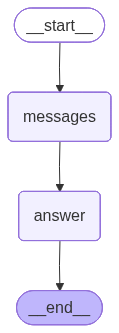

In [88]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### Chat Interface

In [89]:
def chat(user_input: str, history):
    state = State(
        query = [{"role" : "user", "content" : user_input}], 
        output = "", 
        messages=[]
    )
    result = graph.invoke(state)
    print(result)
    return result['output']

In [ ]:
gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.


{'query': [{'role': 'user', 'content': 'hello i am bob'}], 'output': 'Hello Bob! How can I assist you today?', 'messages': [HumanMessage(content="User Query: [{'role': 'user', 'content': 'hello i am bob'}]: LLM Output: ", additional_kwargs={}, response_metadata={}, id='d27cac8c-40c2-4e74-973b-a0fddbd57de4'), AIMessage(content='Hello Bob! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 31, 'total_tokens': 41, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DFPYFMEbe2y7bRDeop89gtUl8Ryx3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--95026cff-6d12-4bb3-9676-8890dc5650f1-0', usage_metadata={'input_tokens': 31, 'o